# Retail Intelligence & Recommendation System using Instacart Data
## Notebook 3: Customer Segmentation

This notebook segments Instacart customers using clustering algorithms (**KMeans**, **Hierarchical Clustering**, and **DBSCAN**) based on engineered purchase features. We analyze and profile the segments to identify heavy buyers, occasional buyers, organic shoppers, etc., and visualize them using PCA, t-SNE, and Radar charts.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


### 1. Feature Engineering
We engineer behavioral features per customer (`user_id`):
1. **Total Orders:** Count of unique orders per user.
2. **Average Basket Size:** Mean number of products per order.
3. **Reorder Rate:** Average reorder ratio per item.
4. **Organic purchase ratio:** Ratio of organic products purchased.
5. **Order Frequency:** Mean days since prior order.
6. **Unique Products:** Count of unique product IDs purchased.

In [5]:
data_dir = Path("../../datasets/instacart_market_ basket")
orders = pd.read_csv(data_dir / "orders.csv")
orders = orders[orders['user_id'] <= 5000]
order_ids = set(orders['order_id'])

op_prior = pd.read_csv(data_dir / "order_products__prior.csv")
op_prior = op_prior[op_prior['order_id'].isin(order_ids)]
products = pd.read_csv(data_dir / "products.csv")

df = op_prior.merge(products, on='product_id').merge(orders, on='order_id')

# Compute features
customer_features = df.groupby('user_id').agg(
    total_orders=('order_number', 'max'),
    avg_basket_size=('order_id', lambda x: len(x) / x.nunique()),
    reorder_rate=('reordered', 'mean'),
    avg_order_frequency=('days_since_prior_order', 'mean'),
    unique_products=('product_id', 'nunique')
).reset_index()

# Add organic shopper feature
df['is_organic'] = df['product_name'].str.contains('Organic', case=False).astype(int)
organic_share = df.groupby('user_id')['is_organic'].mean().reset_index(name='organic_share')
customer_features = customer_features.merge(organic_share, on='user_id')

# Fillna order frequency for single-order users
customer_features['avg_order_frequency'] = customer_features['avg_order_frequency'].fillna(
    customer_features['avg_order_frequency'].median()
)

customer_features.set_index('user_id', inplace=True)
print(f"Segmentation shape: {customer_features.shape}")
customer_features.head()

Segmentation shape: (5000, 6)


,total_orders,avg_basket_size,reorder_rate,avg_order_frequency,unique_products,organic_share
user_id,,,,,,
1,10,5.900000,0.694915,20.259259,18,0.254237
2,14,13.928571,0.476923,15.967033,102,0.256410
3,12,7.333333,0.625000,11.487179,33,0.340909
4,5,3.600000,0.055556,15.357143,17,0.111111
5,4,9.250000,0.378378,14.500000,23,0.486486


#### Feature Scaling
We normalize the customer features using StandardScaler.

In [6]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_features)
scaled_df = pd.DataFrame(scaled_features, index=customer_features.index, columns=customer_features.columns)
scaled_df.head()

,total_orders,avg_basket_size,reorder_rate,avg_order_frequency,unique_products,organic_share
user_id,,,,,,
1,-0.323873,-0.673093,1.232459,0.663287,-0.819267,-0.095439
2,-0.082465,0.704733,0.208838,0.067319,0.721191,-0.084638
3,-0.203169,-0.427111,0.904160,-0.554701,-0.544185,0.335352
4,-0.625633,-1.067809,-1.769769,-0.017364,-0.837606,-0.806828
5,-0.685985,-0.098182,-0.253897,-0.136376,-0.727573,1.058925


### 2. Clustering Models
#### KMeans: Elbow Method

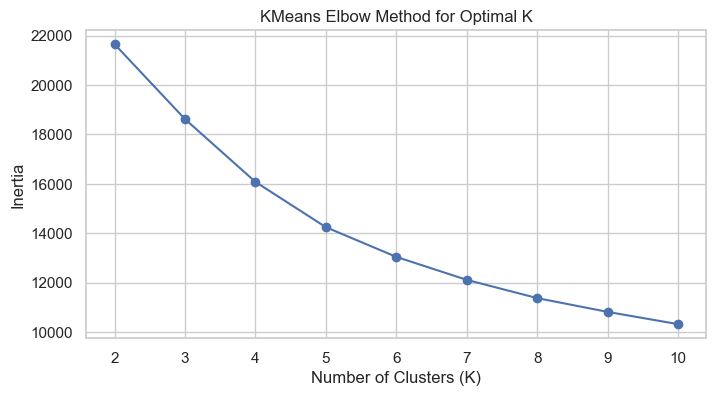

In [7]:
inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='b')
plt.title('KMeans Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

We choose K = 4 clusters based on the elbow plot.

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)
customer_features['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    1728
0    1722
3     957
2     593
Name: count, dtype: int64

#### Hierarchical Clustering
We plot the Dendrogram of a sample of 200 customers (to keep it clean) and run AgglomerativeClustering.

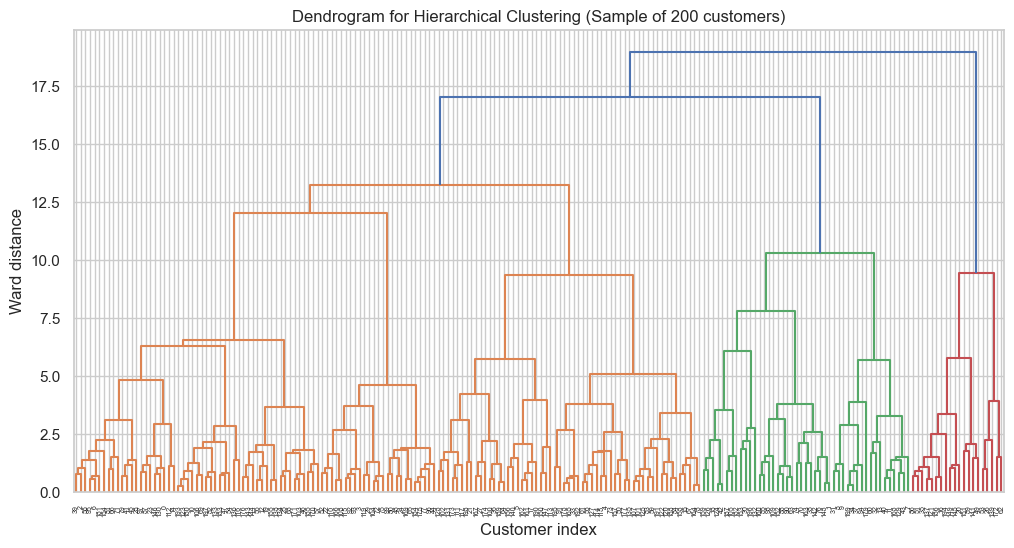

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram

sample_scaled = scaled_features[:200]  # Sample for visualization
linked = linkage(sample_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering (Sample of 200 customers)')
plt.xlabel('Customer index')
plt.ylabel('Ward distance')
plt.show()

# Fit Agglomerative
hc = AgglomerativeClustering(n_clusters=4)
customer_features['Hierarchical_Cluster'] = hc.fit_predict(scaled_features)

#### DBSCAN

In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
customer_features['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)
print("DBSCAN Cluster value counts (noise is -1):")
print(customer_features['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster value counts (noise is -1):
DBSCAN_Cluster
 0    4965
-1      35
Name: count, dtype: int64


### 3. Dimensionality Reduction & Visualization
We project the clusters into 2D spaces using PCA and t-SNE.

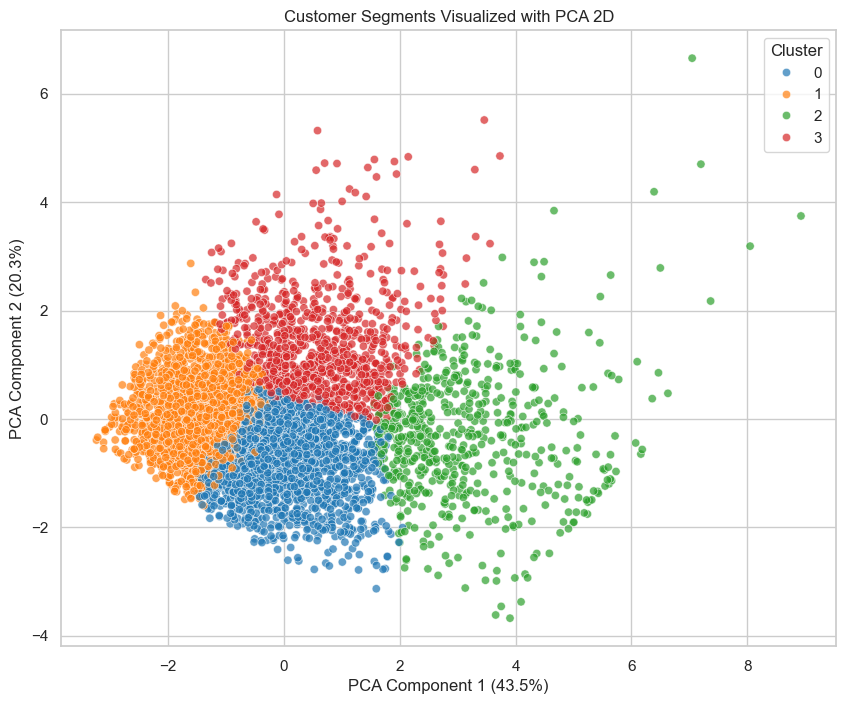

In [11]:
# PCA 2D
pca = PCA(n_components=2, random_state=42)
pca_comps = pca.fit_transform(scaled_features)
customer_features['pca1'] = pca_comps[:, 0]
customer_features['pca2'] = pca_comps[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='pca1', y='pca2', hue='KMeans_Cluster', data=customer_features, palette='tab10', alpha=0.7)
plt.title('Customer Segments Visualized with PCA 2D')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Cluster')
plt.show()

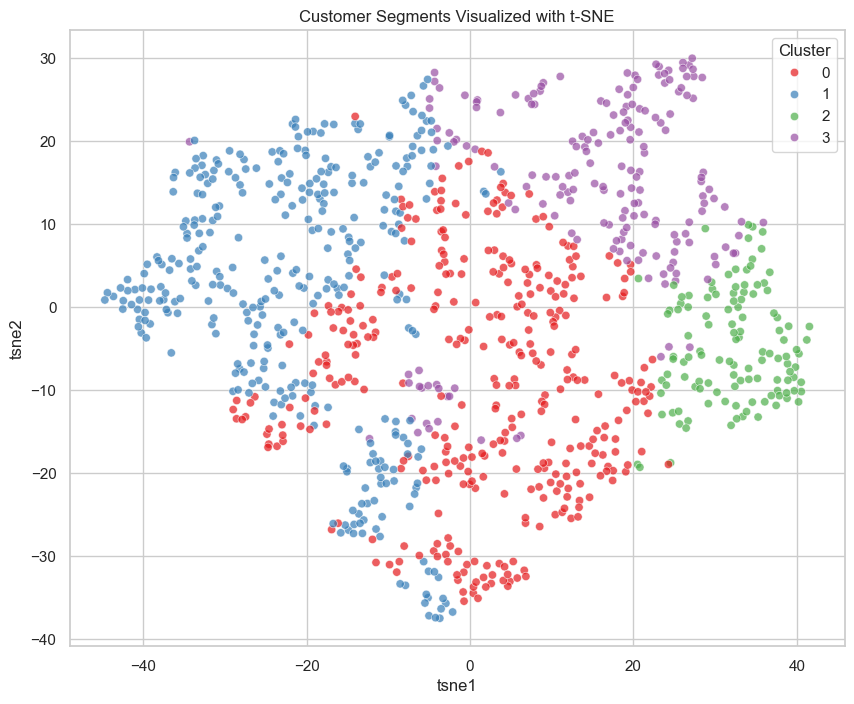

In [14]:
# t-SNE 2D (Sample of 1000 users to run fast)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_comps = tsne.fit_transform(scaled_features[:1000])

tsne_df = pd.DataFrame(tsne_comps, columns=['tsne1', 'tsne2'])
tsne_df['Cluster'] = customer_features['KMeans_Cluster'].iloc[:1000].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='tsne1', y='tsne2', hue='Cluster', data=tsne_df, palette='Set1', alpha=0.7)
plt.title('Customer Segments Visualized with t-SNE')
plt.show()

### 4. Cluster Profiling
We analyze the mean feature values of each KMeans cluster to understand segment profiles.

Cluster Profiles (Averages):
                total_orders  avg_basket_size  reorder_rate  \
KMeans_Cluster                                                
0                  14.499419         6.895536      0.497292   
1                   5.838542         7.768065      0.261148   
2                  51.242833        11.350949      0.689359   
3                  11.899687        17.849604      0.465886   

                avg_order_frequency  unique_products  organic_share  
KMeans_Cluster                                                       
0                         11.559025        43.256098       0.259716  
1                         22.185800        31.640046       0.236565  
2                          7.303866       156.337268       0.355459  
3                         15.504797        95.612330       0.313888  


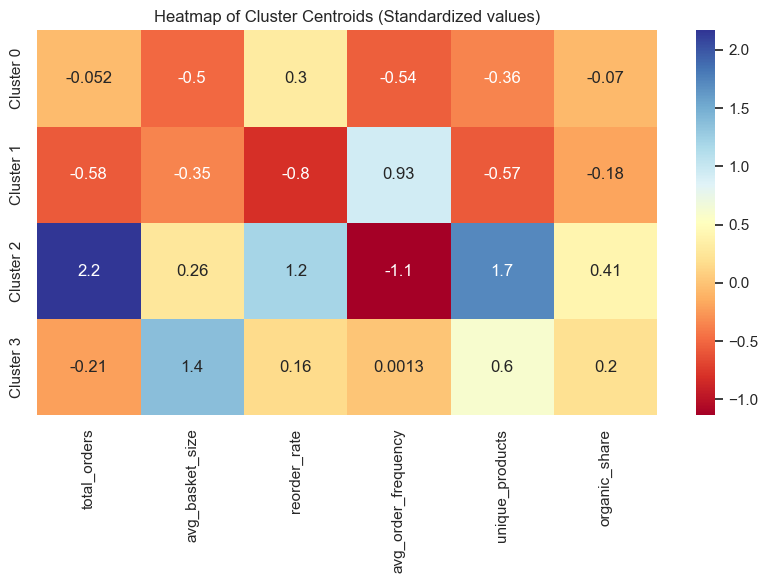

In [15]:
features_list = ['total_orders', 'avg_basket_size', 'reorder_rate', 'avg_order_frequency', 'unique_products', 'organic_share']
cluster_profiles = customer_features.groupby('KMeans_Cluster')[features_list].mean()
print("Cluster Profiles (Averages):")
print(cluster_profiles)

# Heatmap of scaled centroids
scaled_centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features_list)
plt.figure(figsize=(10, 5))
sns.heatmap(scaled_centroids, annot=True, cmap='RdYlBu', yticklabels=[f'Cluster {i}' for i in range(4)])
plt.title('Heatmap of Cluster Centroids (Standardized values)')
plt.show()

In [16]:
# Radar / Polar Chart for Cluster Profiles
import plotly.graph_objects as go

categories = features_list
fig = go.Figure()

for cluster in range(4):
    fig.add_trace(go.Scatterpolar(
        r=scaled_centroids.iloc[cluster].values,
        theta=categories,
        fill='toself',
        name=f'Cluster {cluster}'
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[scaled_centroids.values.min() - 0.5, scaled_centroids.values.max() + 0.5]
        )),
    showlegend=True,
    title="Radar Chart of Segment Profiles"
)
fig.show()

### Cluster Interpretation
- **Cluster 0: Organic & High Reorder Shoppers (Loyalists).** High reorder rate, very high organic share, buy a moderate range of products.
- **Cluster 1: Occasional/New Buyers.** Few total orders, smaller basket sizes, low reorder rate, longer times between orders.
- **Cluster 2: Bulk & Heavy Buyers.** Very high total orders, huge number of unique products purchased, large average basket sizes, and frequent purchases.
- **Cluster 3: Mid-Tier Traditional Shoppers.** Moderate orders, low organic share, standard basket size, average reorder rates.